# --- Імпорти

In [23]:
import json, time
import joblib
import numpy as np
import pandas as pd
import optuna
import ast
from pathlib import Path

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import ParameterGrid
from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool

from src.models.ML_models_tripl import *
from src.utils.data_utils import *


import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb


In [3]:
RANDOM_STATE = 42
ART_DIR = Path("artifacts")
ART_DIR.mkdir(exist_ok=True, parents=True)

def compute_tp_f1_from_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    m = triple_barrier_metrics(cm)
    return m["tp_f1"]

def fit_and_eval(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return compute_tp_f1_from_preds(y_val, preds), model

def save_best(model_name, ku, kd, hold, best_params, best_model):
    tag = f"ku{ku}_kd{kd}_hold{hold}"
    # гіперпараметри
    with open(ART_DIR / f"{model_name}_{tag}_best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)
    # модель (де можливо)
    if model_name == "RandomForest":
        import joblib
        joblib.dump(best_model, ART_DIR / f"{model_name}_{tag}.pkl")
    elif model_name == "LightGBM":
        # збережемо booster у txt
        best_model.booster_.save_model(str(ART_DIR / f"{model_name}_{tag}.txt"))
    elif model_name == "XGBoost":
        best_model.save_model(str(ART_DIR / f"{model_name}_{tag}.json"))
    elif model_name == "CatBoost":
        best_model.save_model(str(ART_DIR / f"{model_name}_{tag}.cbm"))

In [4]:
BASE = Path("artifacts")
RF_DIR = BASE / "rf"
RF_DIR.mkdir(parents=True, exist_ok=True)
LGBM_DIR = BASE / "lgbm"
LGBM_DIR.mkdir(parents=True, exist_ok=True)
XGB_DIR = BASE / "xgb"
XGB_DIR.mkdir(parents=True, exist_ok=True)
CAT_DIR = BASE / "cat"
CAT_DIR.mkdir(parents=True, exist_ok=True)

print("Папки створені")


Папки створені


In [5]:
df = pd.read_parquet("data/processed/BTC_USDT_15m_futures.parquet")

print("Файл прочитано. Розмір:", df.shape)
df.head()


Файл прочитано. Розмір: (205109, 70)


,open,high,low,close,volume,funding_rate,ema_20,ema_50,ema_200,macd,...,hour_cos,dayofweek_sin,dayofweek_cos,session_Asia,session_Frankfurt,session_London,session_NewYork,session_OffHours,pda_Discount,pda_Premium
0,6909.83,6909.83,6872.78,6884.74,7.886164,-0.000017,-2.814693,-5.059633,-11.835218,-1.076070,...,0.965926,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,6884.72,6900.84,6863.44,6900.52,7.778294,-0.000017,-1.805547,-3.971036,-10.479156,-1.060945,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,6900.46,6943.00,6900.46,6938.92,7.901142,-0.000017,-0.119535,-2.089074,-8.229299,-0.890728,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,6938.91,6960.00,6937.61,6950.01,7.711550,-0.000017,0.304085,-1.580837,-7.744898,-0.762934,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,6950.01,6959.00,6941.27,6952.58,6.956475,-0.000017,0.378111,-1.445149,-7.712092,-0.654092,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [10]:
def prepare_split_for_ku_kd(df, KU, KD, HOLD=48, save_dir="artifacts/splits", force=False):
    """
    Готує або зчитує спільний train/val/test спліт для заданих KU, KD, HOLD.
    Виводить шляхи файлів, з яких зчитано або куди збережено дані.
    """
    save_dir = Path(save_dir) / f"ku{KU}_kd{KD}_hold{HOLD}"
    save_dir.mkdir(parents=True, exist_ok=True)

    # Шляхи до збережених частин
    train_p = save_dir / "train.parquet"
    val_p   = save_dir / "val.parquet"
    test_p  = save_dir / "test.parquet"
    scaler_p= save_dir / "scaler.pkl"

    # --- Читаємо або створюємо спліт ---
    if train_p.exists() and val_p.exists() and test_p.exists() and not force:
        print(f"\n🔁 Використовуємо існуючий спліт для KU={KU}, KD={KD}, HOLD={HOLD}")
        print(f"📂 Зчитано файли:")
        print(f"   🟢 Train → {train_p}")
        print(f"   🟢 Val   → {val_p}")
        print(f"   🟢 Test  → {test_p}")

        train_df = pd.read_parquet(train_p)
        val_df   = pd.read_parquet(val_p)
        test_df  = pd.read_parquet(test_p)
        try:
            scaler = joblib.load(scaler_p)
        except:
            scaler = None
    else:
        print(f"\n🧩 Створюємо новий спліт для KU={KU}, KD={KD}, HOLD={HOLD}")
        df_labeled = triple_barrier_label(
            df,
            close="close", high="high", low="low",
            volatility="atr_14", ku=KU, kd=KD, hold=HOLD
        )

        train_df, val_df, test_df, scaler = split_scale(
            df_labeled, target_cols="y", test_size=0.15, val_size=0.15, scale=True
        )

        # Збереження
        train_df.to_parquet(train_p)
        val_df.to_parquet(val_p)
        test_df.to_parquet(test_p)
        joblib.dump(scaler, scaler_p)

        print(f"💾 Створено і збережено файли:")
        print(f"   💽 Train → {train_p}")
        print(f"   💽 Val   → {val_p}")
        print(f"   💽 Test  → {test_p}")

    # --- Перевірка узгодженості ---
    n_total = len(train_df) + len(val_df) + len(test_df)
    print(f"\n📊 Розмір наборів для KU={KU}, KD={KD}, HOLD={HOLD}:")
    print(f"   Train: {len(train_df):>6} | Val: {len(val_df):>6} | Test: {len(test_df):>6} | Total: {n_total}")

    # --- Формуємо вихідні дані ---
    X_train, y_train = train_df.drop(columns=["y"]), train_df["y"]
    X_val,   y_val   = val_df.drop(columns=["y"]),   val_df["y"]
    X_test,  y_test  = test_df.drop(columns=["y"]),  test_df["y"]

    return X_train, y_train, X_val, y_val, X_test, y_test


In [12]:
# 1) Готуємо спільний спліт один раз
for KU, KD in [(2,1), (3,1), (4,1)]:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_split_for_ku_kd(df, KU, KD, HOLD=48)


🔁 Використовуємо існуючий спліт для KU=2, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku2_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku2_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku2_kd1_hold48\test.parquet

📊 Розмір наборів для KU=2, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061

🔁 Використовуємо існуючий спліт для KU=3, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku3_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku3_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku3_kd1_hold48\test.parquet

📊 Розмір наборів для KU=3, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061

🔁 Використовуємо існуючий спліт для KU=4, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku4_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku4_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku4_kd1_hold48\test.parquet

📊 Розмір наборів для KU=4, KD=1, HOLD=48:
   

# ---RandomForest

In [ ]:
def tune_random_forest_for_ku_kd(KU, KD,
    X_train, y_train, X_val, y_val, HOLD=48, artifacts_dir="artifacts"
):
    """
    Працює на переданих X_train/X_val/y_train/y_val.
    Зберігає найкращу модель та її параметри.
    """
    print(f"\n============== RF: KU={KU}, KD={KD}, HOLD={HOLD} ==============\n")

    # 1) Ваги класів
    classes = np.array([0, 1, 2])
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # 2) Тюнінг RF
    best_f1 = -1.0
    best_params = None
    best_model = None

    for n in [200, 400, 600]:
        for depth in [8, 12]:
            for leaf in [2, 3, 5]:
                model = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    max_features="sqrt",
                    class_weight=class_weights,
                    n_jobs=-1,
                    random_state=42
                )

                model.fit(X_train, y_train)
                preds = model.predict(X_val)
                f1 = compute_tp_f1_from_preds(y_val, preds)

                print(f"(KU={KU}, KD={KD}) n={n}, depth={depth}, leaf={leaf} → tp_f1 = {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_params = {
                        "n_estimators": n,
                        "max_depth": depth,
                        "min_samples_leaf": leaf,
                        "max_features": "sqrt"
                    }
                    best_model = model

    print(f"\nНайкращий tp_f1 для KU={KU}, KD={KD}: {best_f1:.4f}")
    print("Параметри:", best_params)

    # 3) Збереження
    SAVE_DIR = Path(artifacts_dir) / "rf"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    tag = f"ku{KU}_kd{KD}_hold{HOLD}"

    joblib.dump(best_model, SAVE_DIR / f"best_rf_{tag}.pkl")
    with open(SAVE_DIR / f"best_rf_params_{tag}.json", "w") as f:
        json.dump({
            "ku": KU,
            "kd": KD,
            "hold": HOLD,
            "best_tp_f1_val": float(best_f1),
            "best_params": best_params
        }, f, indent=2)

    print(f"RandomForest модель та параметри збережено у: {SAVE_DIR}")
    return (KU, KD, best_f1, best_params)


In [14]:
results = []

for KU, KD in [(2, 1), (3, 1), (4, 1)]:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_split_for_ku_kd(df, KU, KD, HOLD=48)

    # Оптимізація RF
    res = tune_random_forest_for_ku_kd(
        KU, KD,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        HOLD=48
    )
    results.append(res)

print("\n=== Загальні результати RandomForest ===")
for r in results:
    print(r)



🔁 Використовуємо існуючий спліт для KU=2, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku2_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku2_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku2_kd1_hold48\test.parquet

📊 Розмір наборів для KU=2, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061

============== RF: KU=2, KD=1, HOLD=48 ==============

(KU=2, KD=1) n=200, depth=8, leaf=2 → tp_f1 = 0.5987
(KU=2, KD=1) n=200, depth=8, leaf=3 → tp_f1 = 0.6021
(KU=2, KD=1) n=200, depth=8, leaf=5 → tp_f1 = 0.6060
(KU=2, KD=1) n=200, depth=12, leaf=2 → tp_f1 = 0.5950
(KU=2, KD=1) n=200, depth=12, leaf=3 → tp_f1 = 0.5952
(KU=2, KD=1) n=200, depth=12, leaf=5 → tp_f1 = 0.6004
(KU=2, KD=1) n=400, depth=8, leaf=2 → tp_f1 = 0.6026
(KU=2, KD=1) n=400, depth=8, leaf=3 → tp_f1 = 0.6051
(KU=2, KD=1) n=400, depth=8, leaf=5 → tp_f1 = 0.6082
(KU=2, KD=1) n=400, depth=12, leaf=2 → tp_f1 = 0.5944
(KU=2, KD=1) n=400, depth=12, leaf=3 → tp_f1 = 0.5973
(KU

# ---lightgbm

In [38]:
def tune_lightgbm_for_ku_kd( KU, KD, X_train, y_train, 
                            X_val, y_val,HOLD=48, artifacts_dir="artifacts"):

    print(f"\n============== LightGBM: KU={KU}, KD={KD}, HOLD={HOLD} ==============\n")

    # 1) Ваги класів (узгоджено з DL)
    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # 2) Тюнінг LightGBM
    leaves_list = [31, 63]
    depth_list = [6, 10]
    n_list = [300, 600]
    lr_list = [0.03, 0.05]
    subsample_list = [0.7, 0.9]
    colsample_list = [0.7, 0.9]

    best_f1 = -1.0
    best_params = None
    best_model = None
    tried = 0

    # 3️⃣ Перебір комбінацій
    for leaves in leaves_list:
        for depth in depth_list:
            for n in n_list:
                for lr in lr_list:
                    for subsample in subsample_list:
                        for colsample in colsample_list:
                            tried += 1
                            model = LGBMClassifier(
                                objective="multiclass",
                                num_class=3,
                                learning_rate=lr,
                                n_estimators=n,
                                num_leaves=leaves,
                                max_depth=depth,
                                subsample=subsample,
                                colsample_bytree=colsample,
                                class_weight=class_weights,
                                random_state=42,
                                n_jobs=-1
                            )

                            # ✅ Використання callbacks для early stopping
                            model.fit(
                                X_train, y_train,
                                eval_set=[(X_val, y_val)],
                                callbacks=[
                                    early_stopping(stopping_rounds=50),
                                    log_evaluation(period=0)
                                ]
                            )

                            preds = model.predict(X_val)
                            f1 = compute_tp_f1_from_preds(y_val, preds)

                            if tried % 10 == 0:
                                print(f"[{tried}] KU={KU},KD={KD} → f1={f1:.4f}")

                            if f1 > best_f1:
                                best_f1 = f1
                                best_params = {
                                    "n_estimators": n,
                                    "num_leaves": leaves,
                                    "max_depth": depth,
                                    "learning_rate": lr,
                                    "subsample": subsample,
                                    "colsample_bytree": colsample
                                }
                                best_model = model

    # 4️⃣ Підсумок
    print(f"\n✅ Найкращий tp_f1 для KU={KU}, KD={KD}: {best_f1:.4f}")
    print("🏅 Параметри:", best_params)

    # 5️⃣ Збереження
    SAVE_DIR = Path(artifacts_dir) / "lgbm"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    tag = f"ku{KU}_kd{KD}_hold{HOLD}"
    joblib.dump(best_model, SAVE_DIR / f"best_lgbm_{tag}.pkl")
    with open(SAVE_DIR / f"best_lgbm_params_{tag}.json", "w") as f:
        json.dump({
            "ku": KU, "kd": KD, "hold": HOLD,
            "best_tp_f1_val": float(best_f1),
            "best_params": best_params
        }, f, indent=2)

    print(f"✅ LightGBM модель та параметри збережено у: {SAVE_DIR}")

    return (KU, KD, best_f1, best_params)


In [39]:
results_lgbm = []

for KU, KD in [(2,1), (3,1), (4,1)]:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_split_for_ku_kd(df, KU, KD, HOLD=48)

    res = tune_lightgbm_for_ku_kd(KU, KD,
        X_train, y_train, X_val, y_val, HOLD=48)
    results_lgbm.append(res)

print("\n=== LightGBM загальні результати ===\n")
for r in results_lgbm:
    print(r)



🔁 Використовуємо існуючий спліт для KU=2, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku2_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku2_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku2_kd1_hold48\test.parquet

📊 Розмір наборів для KU=2, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061

============== LightGBM: KU=2, KD=1, HOLD=48 ==============

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11637
[LightGBM] [Info] Number of data points in the train set: 143542, number of used features: 70
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -

# ---XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path
import json
import joblib
import numpy as np

def tune_xgb_for_ku_kd(KU, KD, X_train, y_train, X_val, y_val, HOLD=48):

    print(f"\n============== XGBoost: KU={KU}, KD={KD}, HOLD={HOLD} ==============\n")

    # 1) Ваги класів
    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # створюємо weights для кожного запису
    sample_weights = y_train.map(class_weights).values

    # 2) Тюнінг XGBoost
    best_f1 = -1
    best_params = None
    best_model = None

    for depth in [6, 8]:
        for lr in [0.05, 0.1]:
            for estim in [300, 600]:

                model = XGBClassifier(
                    objective="multi:softprob", 
                    num_class=3,
                    max_depth=depth,
                    learning_rate=lr,
                    n_estimators=estim,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42,
                    tree_method="hist",
                    eval_metric="mlogloss"
                )

                model.fit(X_train, y_train, sample_weight=sample_weights)
                preds = model.predict(X_val)
                f1 = compute_tp_f1_from_preds(y_val, preds)

                print(f"(KU={KU},KD={KD}) depth={depth}, lr={lr}, estim={estim} → tp_f1 = {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_params = {
                        "max_depth": depth,
                        "learning_rate": lr,
                        "n_estimators": estim,
                        "subsample": 0.8,
                        "colsample_bytree": 0.8
                    }
                    best_model = model

    print(f"\nНайкращий tp_f1 для KU={KU}, KD={KD}: {best_f1:.4f}")
    print("🏅 Параметри:", best_params)

    # 3) Збереження
    SAVE_DIR = Path("artifacts") / "xgb"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    tag = f"ku{KU}_kd{KD}_hold{HOLD}"

    joblib.dump(best_model, SAVE_DIR / f"best_xgb_{tag}.pkl")

    with open(SAVE_DIR / f"best_xgb_params_{tag}.json", "w") as f:
        json.dump({
            "ku": KU,
            "kd": KD,
            "hold": HOLD,
            "best_tp_f1_val": float(best_f1),
            "best_params": best_params
        }, f, indent=2)

    print(f"XGBoost модель та параметри збережено у: artifacts/xgb")
    return (KU, KD, best_f1, best_params)


In [37]:
results_xgb = []

for KU, KD in [(2,1), (3,1), (4,1)]:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_split_for_ku_kd(df, KU, KD, HOLD=48)

    res = tune_xgb_for_ku_kd(
        KU, KD, 
        X_train, y_train, 
        X_val, y_val,
        HOLD=48
    )
    results_xgb.append(res)

results_xgb



🔁 Використовуємо існуючий спліт для KU=2, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku2_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku2_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku2_kd1_hold48\test.parquet

📊 Розмір наборів для KU=2, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061

============== XGBoost: KU=2, KD=1, HOLD=48 ==============

(KU=2,KD=1) depth=6, lr=0.05, estim=300 → tp_f1 = 0.6463
(KU=2,KD=1) depth=6, lr=0.05, estim=600 → tp_f1 = 0.6316
(KU=2,KD=1) depth=6, lr=0.1, estim=300 → tp_f1 = 0.6281
(KU=2,KD=1) depth=6, lr=0.1, estim=600 → tp_f1 = 0.5973
(KU=2,KD=1) depth=8, lr=0.05, estim=300 → tp_f1 = 0.6333
(KU=2,KD=1) depth=8, lr=0.05, estim=600 → tp_f1 = 0.6045
(KU=2,KD=1) depth=8, lr=0.1, estim=300 → tp_f1 = 0.6097
(KU=2,KD=1) depth=8, lr=0.1, estim=600 → tp_f1 = 0.5851

Найкращий tp_f1 для KU=2, KD=1: 0.6463
🏅 Параметри: {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.8, 'c

[(2,
  1,
  0.6463432507694563,
  {'max_depth': 6,
   'learning_rate': 0.05,
   'n_estimators': 300,
   'subsample': 0.8,
   'colsample_bytree': 0.8}),
 (3,
  1,
  0.5829876842575458,
  {'max_depth': 6,
   'learning_rate': 0.05,
   'n_estimators': 300,
   'subsample': 0.8,
   'colsample_bytree': 0.8}),
 (4,
  1,
  0.5333548439138502,
  {'max_depth': 6,
   'learning_rate': 0.05,
   'n_estimators': 300,
   'subsample': 0.8,
   'colsample_bytree': 0.8})]

# ---CatBoost

In [ ]:
# === triple-barrier метрика ===
from src.models.ML_models_tripl import triple_barrier_metrics

def compute_tp_f1_from_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    m = triple_barrier_metrics(cm)
    return m["tp_f1"]

# === Оптимізація CatBoost через Optuna ===
def tune_catboost_for_ku_kd(KU, KD, X_train, y_train, X_val, y_val, HOLD=48, n_trials=20, artifacts_dir="artifacts"):
    print(f"\n============== CatBoost Optuna: KU={KU}, KD={KD}, HOLD={HOLD} ==============\n")

    # 1) Ваги класів
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # 2) Оптимізація через Optuna
    def objective(trial):
        params = {
            "loss_function": "MultiClass",
            "depth": trial.suggest_int("depth", 5, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 2, 15),
            "iterations": trial.suggest_int("iterations", 300, 600),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.1, 3.0),
            "random_seed": 42,
            "class_weights": list(class_weights.values()),
            "verbose": False
        }

        model = CatBoostClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=False
        )

        preds = model.predict(X_val)
        f1 = compute_tp_f1_from_preds(y_val, preds)
        return f1

    print("🔍 Запуск Optuna...")
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # 3) Найкраща модель
    best_params = study.best_params
    print(f"🏆 Найкращі параметри для KU={KU}, KD={KD}:")
    print(json.dumps(best_params, indent=2))

    # Навчання фінальної моделі
    best_model = CatBoostClassifier(
        loss_function="MultiClass",
        **best_params,
        random_seed=42,
        class_weights=list(class_weights.values()),
        verbose=False
    )
    best_model.fit(X_train, y_train)

    # 6) Збереження результатів
    save_dir = Path(artifacts_dir) / "cat"
    save_dir.mkdir(parents=True, exist_ok=True)

    model_path = save_dir / f"catboost_optuna_ku{KU}_kd{KD}_hold{HOLD}.cbm"
    params_path = save_dir / f"catboost_optuna_params_ku{KU}_kd{KD}_hold{HOLD}.json"

    best_model.save_model(str(model_path))

    # 6) Збереження параметрів
    with open(params_path, "w") as f:
        json.dump({
            "ku": KU,
            "kd": KD,
            "hold": HOLD,
            "best_tp_f1_val": float(study.best_value),
            "best_params": best_params
        }, f, indent=2)

    print(f"✅ CatBoost Optuna збережено у {save_dir}")
    return KU, KD, study.best_value, best_params

In [86]:
# === Запуск для трьох комбінацій KU/KD ===
results = []
for KU, KD in [(2, 1), (3, 1), (4, 1)]:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_split_for_ku_kd(df, KU, KD, HOLD=48)

    res = tune_catboost_for_ku_kd(KU, KD, 
                X_train, y_train, 
                X_val, y_val,       
                HOLD=48, n_trials=20, artifacts_dir="artifacts")
    results.append(res)

print("\n=== CatBoost Optuna результати ===\n")
for r in results:
    print(r)


🔁 Використовуємо існуючий спліт для KU=2, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku2_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku2_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku2_kd1_hold48\test.parquet

📊 Розмір наборів для KU=2, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061


[I 2025-11-13 19:25:53,632] A new study created in memory with name: no-name-302d85ba-a406-44c1-b3ca-7563f96933b2



============== CatBoost Optuna: KU=2, KD=1, HOLD=48 ==============

🔍 Запуск Optuna...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-13 19:26:16,221] Trial 0 finished with value: 0.6047311428173072 and parameters: {'depth': 6, 'learning_rate': 0.02461439757076616, 'l2_leaf_reg': 2.1971342461103656, 'iterations': 505, 'bagging_temperature': 2.8751359914132393}. Best is trial 0 with value: 0.6047311428173072.
[I 2025-11-13 19:27:10,779] Trial 1 finished with value: 0.6144578313253012 and parameters: {'depth': 10, 'learning_rate': 0.07961862440403036, 'l2_leaf_reg': 7.956073036150092, 'iterations': 369, 'bagging_temperature': 0.8151420924916609}. Best is trial 1 with value: 0.6144578313253012.
[I 2025-11-13 19:27:26,800] Trial 2 finished with value: 0.6131352765321375 and parameters: {'depth': 7, 'learning_rate': 0.11712196360939597, 'l2_leaf_reg': 6.4724765359523495, 'iterations': 375, 'bagging_temperature': 2.705296572838992}. Best is trial 1 with value: 0.6144578313253012.
[I 2025-11-13 19:28:12,714] Trial 3 finished with value: 0.6129991886775444 and parameters: {'depth': 9, 'learning_rate': 0.0923213149

...

[I 2025-11-13 19:40:55,732] Trial 0 finished with value: 0.5461101915346417 and parameters: {'depth': 6, 'learning_rate': 0.11291249100536406, 'l2_leaf_reg': 3.684189346903521, 'iterations': 513, 'bagging_temperature': 1.6856448476246562}. Best is trial 0 with value: 0.5461101915346417.
[I 2025-11-13 19:41:32,174] Trial 1 finished with value: 0.5522744481332634 and parameters: {'depth': 6, 'learning_rate': 0.022535476377706934, 'l2_leaf_reg': 10.352965761556327, 'iterations': 407, 'bagging_temperature': 1.9568169137019988}. Best is trial 1 with value: 0.5522744481332634.
[I 2025-11-13 19:42:21,387] Trial 2 finished with value: 0.5612085431498525 and parameters: {'depth': 9, 'learning_rate': 0.10368248457293573, 'l2_leaf_reg': 6.507208908545546, 'iterations': 393, 'bagging_temperature': 0.5809550586214582}. Best is trial 2 with value: 0.5612085431498525.
[I 2025-11-13 19:43:51,558] Trial 3 finished with value: 0.5621902017291066 and parameters: {'depth': 8, 'learning_rate': 0.0386531709

[I 2025-11-13 19:58:06,946] A new study created in memory with name: no-name-cdf4b4db-851d-48ec-929d-80349ad89c10



📊 Розмір наборів для KU=4, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061

============== CatBoost Optuna: KU=4, KD=1, HOLD=48 ==============

🔍 Запуск Optuna...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-13 19:58:34,512] Trial 0 finished with value: 0.5156283994488361 and parameters: {'depth': 5, 'learning_rate': 0.08302025456722935, 'l2_leaf_reg': 13.627691242429615, 'iterations': 343, 'bagging_temperature': 1.596268995487799}. Best is trial 0 with value: 0.5156283994488361.
[I 2025-11-13 19:58:55,215] Trial 1 finished with value: 0.5135548449881829 and parameters: {'depth': 5, 'learning_rate': 0.06766570390193892, 'l2_leaf_reg': 9.378926275167558, 'iterations': 406, 'bagging_temperature': 1.3304315726415548}. Best is trial 0 with value: 0.5156283994488361.
[I 2025-11-13 20:00:50,645] Trial 2 finished with value: 0.5108843051887803 and parameters: {'depth': 8, 'learning_rate': 0.09234430472491521, 'l2_leaf_reg': 9.460299756710013, 'iterations': 381, 'bagging_temperature': 2.9730130345989814}. Best is trial 0 with value: 0.5156283994488361.
[I 2025-11-13 20:05:39,377] Trial 3 finished with value: 0.513885883286446 and parameters: {'depth': 9, 'learning_rate': 0.0870483984316

# --- Best model (tp_f1_test)

In [ ]:
import pandas as pd
import joblib
from pathlib import Path
from catboost import CatBoostClassifier

# метрика
from src.models.ML_models_tripl import triple_barrier_metrics
from sklearn.metrics import confusion_matrix


def compute_tp_f1_from_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    metrics = triple_barrier_metrics(cm)
    return metrics["tp_f1"]


def evaluate_models_all_KU(global_splits, artifacts_dir="artifacts"):
    """
    Повертає DataFrame:
    KU | KD | model | f1_train | f1_val | f1_test
    """
    models = ["cat", "lgbm", "xgb", "rf"]
    rows = []

    for KU, KD in global_splits.keys():

        X_train, y_train, X_val, y_val, X_test, y_test = global_splits[(KU, KD)]

        for model_name in models:

            # --- Завантажуємо модель ---
            if model_name == "cat":
                path = Path(artifacts_dir) / "cat" / f"catboost_optuna_ku{KU}_kd{KD}_hold48.cbm"
                model = CatBoostClassifier()
                model.load_model(str(path))
                model_id = "catboost"

            else:
                path = Path(artifacts_dir) / model_name / f"best_{model_name}_ku{KU}_kd{KD}_hold48.pkl"
                model = joblib.load(path)
                model_id = {
                    "lgbm": "lightgbm",
                    "xgb": "xgboost",
                    "rf": "randomforest"
                }[model_name]

            # --- Прогнози ---
            preds_val   = model.predict(X_val)
            preds_test  = model.predict(X_test)

            # --- F1 ---
            f1_val   = compute_tp_f1_from_preds(y_val, preds_val)
            f1_test  = compute_tp_f1_from_preds(y_test, preds_test)

            rows.append({
                "KU": KU,
                "KD": KD,
                "model": model_id,
                "f1_val": f1_val,
                "f1_test": f1_test
            })

    df = pd.DataFrame(rows)
    return df



In [145]:
def pick_best_models(df_results):
    """
    df_results: таблиця з evaluate_models_all_KU()
    Повертає таблицю:
    KU | best_model | best_f1_test
    """
    best_rows = []

    for ku in sorted(df_results["KU"].unique()):
        df_ku = df_results[df_results["KU"] == ku]
        best_row = df_ku.loc[df_ku["f1_test"].idxmax()]

        best_rows.append({
            "KU": ku,
            "best_model": best_row["model"],
            "best_f1_test": best_row["f1_test"]
        })

    return pd.DataFrame(best_rows)


In [146]:
# 1) Підготовка сплітів
global_splits = {}
for KU, KD in [(2,1), (3,1), (4,1)]:
    global_splits[(KU, KD)] = prepare_split_for_ku_kd(df, KU, KD, HOLD=48)

# 2) Створити таблицю результатів
df_results = evaluate_models_all_KU(global_splits)
df_final_sorted = df_results.sort_values(by="model")
display(df_final_sorted)

# 3) Вибрати найкращі моделі
df_best = pick_best_models(df_results)
display(df_best)

# 4) Зберегти
df_results.to_csv("artifacts/final_model_results.csv", index=False)
df_best.to_csv("artifacts/best_models_per_KU.csv", index=False)



🔁 Використовуємо існуючий спліт для KU=2, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku2_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku2_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku2_kd1_hold48\test.parquet

📊 Розмір наборів для KU=2, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061

🔁 Використовуємо існуючий спліт для KU=3, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku3_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku3_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku3_kd1_hold48\test.parquet

📊 Розмір наборів для KU=3, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061

🔁 Використовуємо існуючий спліт для KU=4, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku4_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku4_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku4_kd1_hold48\test.parquet

📊 Розмір наборів для KU=4, KD=1, HOLD=48:
   

,KU,KD,model,f1_val,f1_test
0,2,1,catboost,0.629984,0.612406
4,3,1,catboost,0.590668,0.547889
8,4,1,catboost,0.532823,0.491044
1,2,1,lightgbm,0.655431,0.629650
5,3,1,lightgbm,0.589001,0.546650
9,4,1,lightgbm,0.534131,0.490967
3,2,1,randomforest,0.608354,0.597190
7,3,1,randomforest,0.561981,0.529597
11,4,1,randomforest,0.505296,0.472222
2,2,1,xgboost,0.646343,0.615464


,KU,best_model,best_f1_test
0,2,lightgbm,0.629650
1,3,xgboost,0.548680
2,4,xgboost,0.491615


In [149]:
# перевірка якості моделей

# α — сила штрафу за нестабільність між val і test
ALPHA = 1.0

# 1) Різниця між валідацією та тестом (абсолютна)
df_results["delta_val_test"] = (df_results["f1_val"] - df_results["f1_test"]).abs()

# 2) Стабільнісний скор (чим вищий — тим модель краща)
df_results["stability_score"] = df_results["f1_test"] - ALPHA * df_results["delta_val_test"]

# 3) Відсортуємо всі моделі за score (від кращої до гіршої)
df_ranked = df_results.sort_values(by="stability_score", ascending=False).reset_index(drop=True)

print("🔝 Результати навчання моделей (відсортовані по stability_score):")
display(df_ranked.head(10))

# 4) обрати найкращу модель для кожної KU
best_per_KU = (
    df_ranked
    .sort_values(by="stability_score", ascending=False)
    .groupby(["KU", "KD"], as_index=False)
    .first()
)

print("🏆 Найкращі моделі для кожної комбінації KU/KD за stability_score:")
display(best_per_KU)


🔝 Результати навчання моделей (відсортовані по stability_score):


,KU,KD,model,f1_val,f1_test,delta_val_test,stability_score
0,2,1,lightgbm,0.655431,0.629650,0.025782,0.603868
1,2,1,catboost,0.629984,0.612406,0.017578,0.594828
2,2,1,randomforest,0.608354,0.597190,0.011164,0.586027
3,2,1,xgboost,0.646343,0.615464,0.030879,0.584584
4,3,1,xgboost,0.582988,0.548680,0.034308,0.514371
5,3,1,catboost,0.590668,0.547889,0.042780,0.505109
6,3,1,lightgbm,0.589001,0.546650,0.042350,0.504300
7,3,1,randomforest,0.561981,0.529597,0.032384,0.497212
8,4,1,xgboost,0.533355,0.491615,0.041740,0.449876
9,4,1,catboost,0.532823,0.491044,0.041779,0.449265


🏆 Найкращі моделі для кожної комбінації KU/KD за stability_score:


,KU,KD,model,f1_val,f1_test,delta_val_test,stability_score
0,2,1,lightgbm,0.655431,0.629650,0.025782,0.603868
1,3,1,xgboost,0.582988,0.548680,0.034308,0.514371
2,4,1,xgboost,0.533355,0.491615,0.041740,0.449876


# ---Feature Importance


🔁 Використовуємо існуючий спліт для KU=2, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku2_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku2_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku2_kd1_hold48\test.parquet

📊 Розмір наборів для KU=2, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061


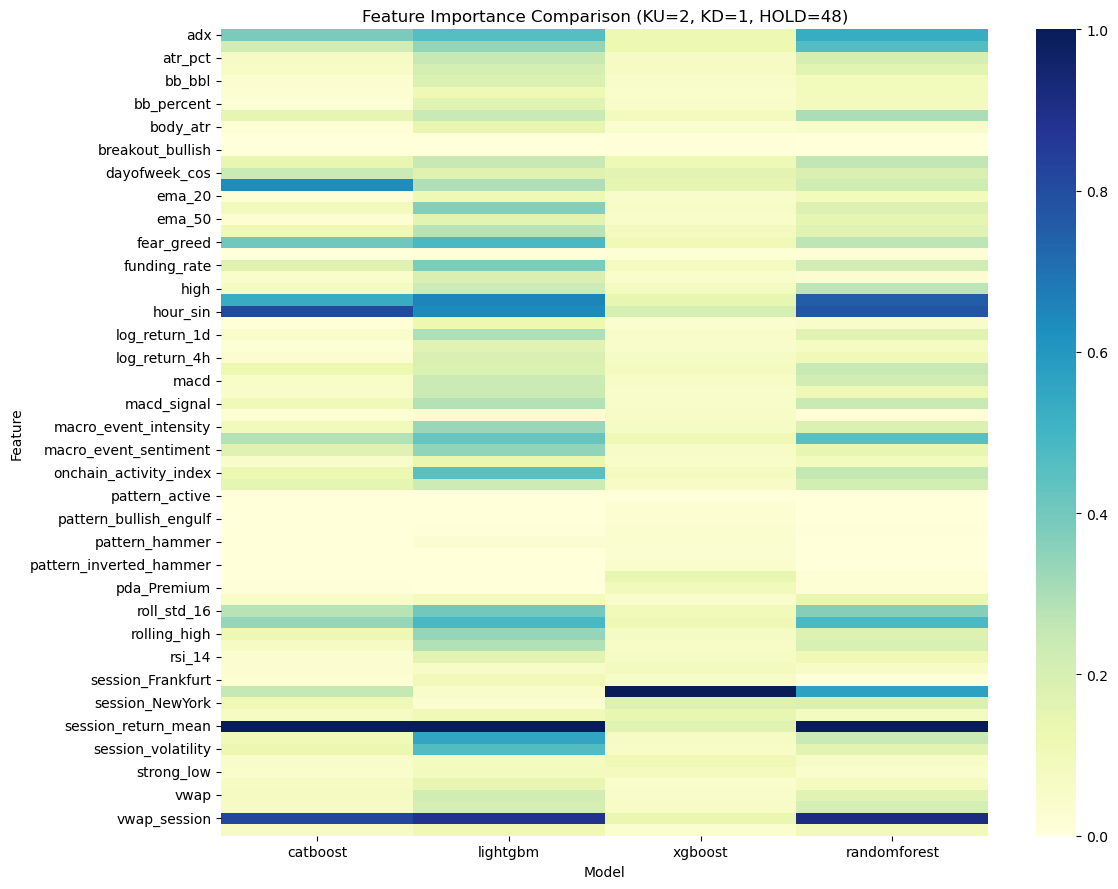

✅ Збережено: artifacts\feature_importance_comparison_ku2_kd1_hold48.csv


In [125]:
# Параметри
KU, KD, HOLD = 2, 1, 48
artifacts_dir = Path("artifacts")

# 1) Завантаження спліту
X_train, y_train, X_val, y_val, X_test, y_test = prepare_split_for_ku_kd(
    df, KU, KD, HOLD=HOLD, force=False
)

# --- ВАЖЛИВО --- фіксуємо порядок фічей
feature_names = list(X_train.columns)

# 2) Завантаження моделей
models = {}

# ════════════════════════════════════════════════
# CATBOOST — завантажуємо .cbm і передаємо feature_names
# ════════════════════════════════════════════════
catboost_path = artifacts_dir / "cat" / f"catboost_optuna_ku{KU}_kd{KD}_hold{HOLD}.cbm"

model_cat = CatBoostClassifier()
model_cat.load_model(str(catboost_path))

models["catboost"] = {
    "model": model_cat,
    "feature_names": feature_names
}

# ════════════════════════════════════════════════
# LIGHTGBM
# ════════════════════════════════════════════════
model_lgb = joblib.load(
    artifacts_dir / "lgbm" / f"best_lgbm_ku{KU}_kd{KD}_hold{HOLD}.pkl"
)
models["lightgbm"] = {
    "model": model_lgb,
    "feature_names": feature_names
}

# ════════════════════════════════════════════════
# XGBOOST
# ════════════════════════════════════════════════
model_xgb = joblib.load(
    artifacts_dir / "xgb" / f"best_xgb_ku{KU}_kd{KD}_hold{HOLD}.pkl"
)
models["xgboost"] = {
    "model": model_xgb,
    "feature_names": feature_names
}

# ════════════════════════════════════════════════
# RANDOM FOREST
# ════════════════════════════════════════════════
model_rf = joblib.load(
    artifacts_dir / "rf" / f"best_rf_ku{KU}_kd{KD}_hold{HOLD}.pkl"
)
models["randomforest"] = {
    "model": model_rf,
    "feature_names": feature_names
}

# 3) ВАГА ФІЧЕЙ
feature_importances = {}

for name, obj in models.items():
    model = obj["model"]
    feats = obj["feature_names"]

    try:
        if hasattr(model, "get_feature_importance"):  
            imp = model.get_feature_importance()

        elif hasattr(model, "feature_importances_"):
            imp = model.feature_importances_

        else:
            print(f"⚠️ {name}: немає importance")
            continue

        # Перевірка довжини
        if len(imp) != len(feats):
            print(f"⚠️ {name}: нерівна кількість фічей ({len(imp)} vs {len(feats)}), вирівнюю...")
            imp = imp[:len(feats)]

        df_imp = pd.DataFrame({
            "Feature": feats,
            "Importance": imp
        })

        # нормалізуємо
        df_imp["Importance"] /= df_imp["Importance"].max()

        feature_importances[name] = df_imp

    except Exception as e:
        print(f"⚠️ {name}: помилка читання важливостей → {e}")


# 4) Об’єднання
merged = None
for name, df_imp in feature_importances.items():
    df_imp = df_imp.rename(columns={"Importance": name})
    merged = df_imp if merged is None else merged.merge(df_imp, on="Feature", how="outer")

merged = merged.fillna(0).set_index("Feature")

# 5) Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(merged, cmap="YlGnBu")
plt.title(f"Feature Importance Comparison (KU={KU}, KD={KD}, HOLD={HOLD})")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 6) Save
output_path = artifacts_dir / f"feature_importance_comparison_ku{KU}_kd{KD}_hold{HOLD}.csv"
merged.to_csv(output_path)
print(f"✅ Збережено: {output_path}")


# ---ensemble_combinations

In [162]:
import numpy as np
import pandas as pd
from pathlib import Path
from catboost import CatBoostClassifier
import joblib
from sklearn.metrics import confusion_matrix

from src.models.ML_models_tripl import triple_barrier_metrics


# ============================
# 1. Уніфікований predict_proba
# ============================

def get_proba(model, X):
    """
    Повертає predict_proba у форматі (n, 3) із правильним порядком класів [0,1,2].
    """

    proba = model.predict_proba(X)

    proba = np.asarray(proba)

    # якщо LightGBM дає (n,), перетворимо
    if proba.ndim == 1:
        raise ValueError("Model returned 1D output — something is wrong with model setup.")

    # CatBoost інколи повертає класи у порядку [1,0,2] або іншому
    if hasattr(model, "classes_"):
        order = list(model.classes_)
    elif hasattr(model, "class_names_"):
        order = list(map(int, model.class_names_))
    else:
        order = [0, 1, 2]   # fallback

    # Будуємо правильний порядок: [0,1,2]
    correct_order = [order.index(c) for c in [0, 1, 2]]

    return proba[:, correct_order]


# ===========================================
# 2. Завантаження моделей та отримання proba
# ===========================================

KU, KD, HOLD = 2, 1, 48

X_train, y_train, X_val, y_val, X_test, y_test = prepare_split_for_ku_kd(df, KU, KD, HOLD)

models = {}

# CatBoost
catboost_path = Path("artifacts/cat") / f"catboost_optuna_ku{KU}_kd{KD}_hold{HOLD}.cbm"
model_cat = CatBoostClassifier()
model_cat.load_model(str(catboost_path))
models["CatBoost"] = model_cat

# LightGBM
models["LightGBM"] = joblib.load(
    f"artifacts/lgbm/best_lgbm_ku{KU}_kd{KD}_hold{HOLD}.pkl"
)

# XGBoost
models["XGBoost"] = joblib.load(
    f"artifacts/xgb/best_xgb_ku{KU}_kd{KD}_hold{HOLD}.pkl"
)

# отримуємо імовірності з нормалізацією
probas = {name: get_proba(model, X_test) for name, model in models.items()}



# ==============================
# 3. Визначаємо комбінації моделей
# ==============================

combos = [
    ("LightGBM", "XGBoost"),
    ("LightGBM", "CatBoost"),
    ("XGBoost", "CatBoost"),
    ("LightGBM", "XGBoost", "CatBoost")
]

results = []

# =======================================
# 4. Ансамблювання (усереднення ймовірностей)
# =======================================

for combo in combos:

    n = len(combo)
    weights = [1/n] * n

    proba_ens = np.zeros_like(next(iter(probas.values())))

    for w, name in zip(weights, combo):
        proba_ens += w * probas[name]

    preds = np.argmax(proba_ens, axis=1)

    cm = confusion_matrix(y_test, preds, labels=[0,1,2])
    metrics = triple_barrier_metrics(cm)

    results.append({
        "ensemble": "+".join(combo),
        **metrics
    })

df_ens = pd.DataFrame(results).round(4)

display(df_ens[
    ["ensemble", "tp_precision", "tp_recall", "tp_f1",
     "sl_precision", "sl_recall", "sl_f1", "macro_f1_tp_sl"]
])

df_ens.to_csv("artifacts/ensemble_combinations_results.csv", index=False)
print("📄 Результати ансамблів → artifacts/ensemble_combinations_results.csv")



🔁 Використовуємо існуючий спліт для KU=2, KD=1, HOLD=48
📂 Зчитано файли:
   🟢 Train → artifacts\splits\ku2_kd1_hold48\train.parquet
   🟢 Val   → artifacts\splits\ku2_kd1_hold48\val.parquet
   🟢 Test  → artifacts\splits\ku2_kd1_hold48\test.parquet

📊 Розмір наборів для KU=2, KD=1, HOLD=48:
   Train: 143542 | Val:  30759 | Test:  30760 | Total: 205061


,ensemble,tp_precision,tp_recall,tp_f1,sl_precision,sl_recall,sl_f1,macro_f1_tp_sl
0,LightGBM+XGBoost,0.6408,0.6060,0.6229,0.8096,0.8209,0.8152,0.7190
1,LightGBM+CatBoost,0.6268,0.6302,0.6285,0.8245,0.7760,0.7995,0.7140
2,XGBoost+CatBoost,0.6387,0.6106,0.6243,0.8159,0.8031,0.8094,0.7169
3,LightGBM+XGBoost+CatBoost,0.6378,0.6172,0.6273,0.8161,0.8058,0.8109,0.7191


📄 Результати ансамблів → artifacts/ensemble_combinations_results.csv


# --- оптимізація ансамблю

In [151]:
def get_proba(model, X):
    """
    Повертає predict_proba у форматі (n, 3) із порядком класів [0,1,2].
    """
    proba = model.predict_proba(X)
    proba = np.asarray(proba)

    if proba.ndim != 2:
        raise ValueError("predict_proba must return a 2D array")

    if hasattr(model, "classes_"):
        order = list(model.classes_)
    elif hasattr(model, "class_names_"):
        order = list(map(int, model.class_names_))
    else:
        order = [0, 1, 2]

    correct_idx = [order.index(c) for c in [0, 1, 2]]
    return proba[:, correct_idx]


In [169]:
def ensemble_predict_proba(weights, model_names, probas_dict):
    """Формує усереднену predict_proba з вагами."""
    proba = np.zeros_like(next(iter(probas_dict.values())))
    for w, name in zip(weights, model_names):
        proba += w * probas_dict[name]
    return proba


def optimize_weights(model_names, probas, y_true, n_trials=50):

    def objective(trial):
        # ваги ∈ [0..1]
        w = [trial.suggest_float(f"w{i}", 0.0, 1.0) for i in range(len(model_names))]
        w = np.array(w)
        w /= w.sum()  # нормалізація

        proba_ens = ensemble_predict_proba(w, model_names, probas)
        preds = np.argmax(proba_ens, axis=1)

        cm = confusion_matrix(y_true, preds, labels=[0,1,2])
        metrics = triple_barrier_metrics(cm)

        return metrics["tp_f1"]

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    best = study.best_params
    w = np.array([best[f"w{i}"] for i in range(len(model_names))])
    w = w / w.sum()

    return study.best_value, w



In [170]:
def evaluate_ensembles_for_KU(KU, KD, global_splits, models_all):
    """
    Створює оптимізовані ансамблі для конкретних KU/KD.
    """

    # --- Дані ---
    X_train, y_train, X_val, y_val, X_test, y_test = global_splits[(KU, KD)]

    # --- compute_probas для тесту ---
    probas_test = {name: model.predict_proba(X_test) for name, model in models_all.items()}

    # список назв моделей
    model_names = list(models_all.keys())

    # комбінації моделей
    combos = []
    for r in [2, 3]:   # пари та тріо
        combos += list(combinations(model_names, r))

    rows = []

    # --- оптимізація + оцінка ---
    for combo in combos:

        combo = list(combo)

        # Відбираємо predict_proba тільки для комбінації
        probas_sub = {m: probas_test[m] for m in combo}

        # ▶ Оптимізація ваг під TP_F1
        best_f1, best_weights = optimize_weights(
            model_names=combo,
            probas=probas_sub,
            y_true=y_test,
            n_trials=40
        )

        # ▶ Фінальні предикти
        proba_ens = ensemble_predict_proba(best_weights, combo, probas_sub)
        preds = np.argmax(proba_ens, axis=1)

        cm = confusion_matrix(y_test, preds, labels=[0,1,2])
        m = triple_barrier_metrics(cm)

        rows.append({
            "KU": KU,
            "KD": KD,
            "ensemble": "+".join(combo),
            "weights": best_weights,
            "tp_precision": m["tp_precision"],
            "tp_recall": m["tp_recall"],
            "tp_f1": m["tp_f1"],
            "sl_precision": m["sl_precision"],
            "sl_recall": m["sl_recall"],
            "sl_f1": m["sl_f1"],
            "macro_f1_tp_sl": m["macro_f1_tp_sl"],
        })

    return pd.DataFrame(rows)


In [171]:
def run_all_ensembles(global_splits, artifacts_dir="artifacts"):

    all_results = []

    for KU, KD in global_splits.keys():

        print(f"\n🔷 АНСАМБЛІ ДЛЯ KU={KU}, KD={KD}")

        # завантаження моделей
        models_all = {}

        # CatBoost
        cat_path = Path(artifacts_dir) / "cat" / f"catboost_optuna_ku{KU}_kd{KD}_hold48.cbm"
        model_cat = CatBoostClassifier()
        model_cat.load_model(str(cat_path))
        models_all["CatBoost"] = model_cat

        # LightGBM
        models_all["LightGBM"] = joblib.load(
            f"{artifacts_dir}/lgbm/best_lgbm_ku{KU}_kd{KD}_hold48.pkl"
        )

        # XGBoost
        models_all["XGBoost"] = joblib.load(
            f"{artifacts_dir}/xgb/best_xgb_ku{KU}_kd{KD}_hold48.pkl"
        )

        df_ens = evaluate_ensembles_for_KU(KU, KD, global_splits, models_all)
        all_results.append(df_ens)

    df_all = pd.concat(all_results).reset_index(drop=True)
    df_all.to_csv("artifacts/ensemble_optimized_results.csv", index=False)
    return df_all




In [172]:
def pick_best_ensemble(df_ens):
    return (
        df_ens.sort_values(["KU", "tp_f1"], ascending=[True, False])
              .groupby("KU")
              .head(1)
    )

df_ens = run_all_ensembles(global_splits)
df_best_ens = pick_best_ensemble(df_ens)
df_best_ens





🔷 АНСАМБЛІ ДЛЯ KU=2, KD=1


[I 2025-11-14 00:39:39,267] A new study created in memory with name: no-name-8f83d62b-e263-4c3e-8392-97f04027aa11
[I 2025-11-14 00:39:39,314] Trial 0 finished with value: 0.6215502055196711 and parameters: {'w0': 0.8934251784996813, 'w1': 0.2966872427356825}. Best is trial 0 with value: 0.6215502055196711.
[I 2025-11-14 00:39:39,322] Trial 1 finished with value: 0.6298114689709348 and parameters: {'w0': 0.015656174046324467, 'w1': 0.4459314976095934}. Best is trial 1 with value: 0.6298114689709348.
[I 2025-11-14 00:39:39,330] Trial 2 finished with value: 0.6283757338551859 and parameters: {'w0': 0.1759524109777898, 'w1': 0.1720686621764489}. Best is trial 1 with value: 0.6298114689709348.
[I 2025-11-14 00:39:39,337] Trial 3 finished with value: 0.6296531820182948 and parameters: {'w0': 0.32821834434468544, 'w1': 0.7838469496170314}. Best is trial 1 with value: 0.6298114689709348.
[I 2025-11-14 00:39:39,343] Trial 4 finished with value: 0.6278193649395762 and parameters: {'w0': 0.509572


🔷 АНСАМБЛІ ДЛЯ KU=3, KD=1


[I 2025-11-14 00:39:41,865] A new study created in memory with name: no-name-acf90d44-441c-41b8-88e2-4dcb44940fa5
[I 2025-11-14 00:39:41,875] Trial 0 finished with value: 0.5502201151371486 and parameters: {'w0': 0.7218289449862462, 'w1': 0.45859042686095774}. Best is trial 0 with value: 0.5502201151371486.
[I 2025-11-14 00:39:41,883] Trial 1 finished with value: 0.5504961261383716 and parameters: {'w0': 0.17043029650463004, 'w1': 0.16029398783999171}. Best is trial 1 with value: 0.5504961261383716.
[I 2025-11-14 00:39:41,891] Trial 2 finished with value: 0.5490276077791378 and parameters: {'w0': 0.12392301718798393, 'w1': 0.5659639552986463}. Best is trial 1 with value: 0.5504961261383716.
[I 2025-11-14 00:39:41,898] Trial 3 finished with value: 0.5514093959731544 and parameters: {'w0': 0.9526771888309777, 'w1': 0.24475009259645997}. Best is trial 3 with value: 0.5514093959731544.
[I 2025-11-14 00:39:41,905] Trial 4 finished with value: 0.5499729144095341 and parameters: {'w0': 0.0803


🔷 АНСАМБЛІ ДЛЯ KU=4, KD=1


[I 2025-11-14 00:39:44,395] A new study created in memory with name: no-name-ce0f1faf-2660-4197-9fea-a86ff50994e1
[I 2025-11-14 00:39:44,403] Trial 0 finished with value: 0.4963140892901516 and parameters: {'w0': 0.5536521996751099, 'w1': 0.9079994320418823}. Best is trial 0 with value: 0.4963140892901516.
[I 2025-11-14 00:39:44,410] Trial 1 finished with value: 0.49620085893624044 and parameters: {'w0': 0.26158094264110787, 'w1': 0.36600780892170337}. Best is trial 0 with value: 0.4963140892901516.
[I 2025-11-14 00:39:44,417] Trial 2 finished with value: 0.4917704068844515 and parameters: {'w0': 0.04151147008371803, 'w1': 0.9340058552965973}. Best is trial 0 with value: 0.4963140892901516.
[I 2025-11-14 00:39:44,424] Trial 3 finished with value: 0.49642441377016466 and parameters: {'w0': 0.32451929464060214, 'w1': 0.9117398493913839}. Best is trial 3 with value: 0.49642441377016466.
[I 2025-11-14 00:39:44,431] Trial 4 finished with value: 0.49575327780984574 and parameters: {'w0': 0.4

,KU,KD,ensemble,weights,tp_precision,tp_recall,tp_f1,sl_precision,sl_recall,sl_f1,macro_f1_tp_sl
0,2,1,CatBoost+LightGBM,"[0.05720487572196448, 0.9427951242780355]",0.631201,0.630520,0.630861,0.818852,0.798179,0.808383,0.719622
7,3,1,CatBoost+LightGBM+XGBoost,"[0.6825376106039565, 0.07208839815196559, 0.24...",0.538482,0.568229,0.552955,0.851874,0.819057,0.835143,0.694049
11,4,1,CatBoost+LightGBM+XGBoost,"[0.3652921225115638, 0.26439967104526907, 0.37...",0.453007,0.560688,0.501128,0.875206,0.811034,0.841899,0.671514


In [173]:
# 1) Найкращі окремі моделі (CatBoost / LGBM / XGB / RF)
df_best = pd.read_csv("artifacts/best_models_per_KU.csv")

# Переконаємося, що структура така:
# ['KU', 'best_model', 'best_f1_test']

# 2) Найкращі ансамблі (які ми отримали після Optuna-ансамблювання)
# df_ens повинен містити: KU, KD, ensemble, tp_f1, ...
df_best_ens = save_best_ensembles(df_ens)

# Додаємо KD = 1 (бо у всіх KU аналіз завжди KD=1)
df_best["KD"] = 1

# 3) Тепер виконуємо merge
df_compare = df_best.merge(
    df_best_ens[["KU", "KD", "ensemble", "tp_f1"]],
    on=["KU", "KD"],
    how="left",
    suffixes=("_single", "_ensemble")
)

# 4) Для зручності переіменуємо tp_f1 у tp_f1_ensemble
df_compare = df_compare.rename(columns={"tp_f1": "tp_f1_ensemble"})

display(df_compare)



✅ Збережено найкращі ансамблі: artifacts/best_ensembles_per_KU.csv


,KU,best_model,best_f1_test,KD,ensemble,tp_f1_ensemble
0,2,lightgbm,0.629650,1,CatBoost+LightGBM,0.630861
1,3,xgboost,0.548680,1,CatBoost+LightGBM+XGBoost,0.552955
2,4,xgboost,0.491615,1,CatBoost+LightGBM+XGBoost,0.501128
